In [ ]:
import time

start_time = time.time()
print(f"Start time recorded: {start_time}")

Start time recorded: 1762772564.1833591


<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/phonchi/CryoParticleSegment/blob/main/notebook/05_cryosparc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

## ⭐ Setup
You must run all codes under this category.

In [ ]:
# @title packages imports

import os
import subprocess
import json
import socket
import re
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

### ✅ Directory Settings

In [ ]:
# @title  { display-mode: "form" }
# @markdown Directory parameters.

DATA_DIR = "/content/dataset" # @param {type:"string"}
Input_MICROGRAPH_DATA_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output" # @param {type: "string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_100_CDF/10017" # @param {type:"string"}
STAR_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_100_CDF/10017/unet_eb5_dice_CRF" # @param {type:"string"}
TMP_DIR = "/content/tmp" # @param {type:"string"}
SOFTWARE_DIR = "/content/software" # @param {type:"string"}
PROJECT_DIR = "/content/sparc_project" # @param {type:"string"}
WORK_DIR = os.getcwd()

In [ ]:
# @title  { display-mode: "form" }
# @markdown Run this block if using folder📁 in Google Drive as **`RESULT_DIR`**.

try:
  from google.colab import drive
  drive.mount('/content/drive')
except:
  pass

Mounted at /content/drive


In [ ]:
# @title  { display-mode: "form" }
# @markdown Run this block for remove the **`sample_data`** folder📁 in content

if os.path.isdir("/content/sample_data"):
  !rm -r /content/sample_data
# from shutil import rmtree
#
# rmtree(f"/content/sample_data")

In [ ]:
# @title  { display-mode: "form" }
# @markdown Run this block for checking the existence of the directories

if not os.path.isdir(DATA_DIR):
  os.mkdir(DATA_DIR)

if not os.path.isdir(RESULT_DIR):
  os.mkdir(RESULT_DIR)

if not os.path.isdir(TMP_DIR):
  os.mkdir(TMP_DIR)

if not os.path.isdir(SOFTWARE_DIR):
  os.mkdir(SOFTWARE_DIR)


if not os.path.isdir(PROJECT_DIR):
  os.mkdir(PROJECT_DIR)

### ✅ EMPIAR Data Setting

In [ ]:
# @title  { vertical-output: true, display-mode: "form" }
EMPIAR_ID = 10017 # @param {type:"integer"}

In [ ]:
EMPIAR_DIR = os.path.join(DATA_DIR, f"EMPIAR-{EMPIAR_ID}")
!mkdir {EMPIAR_DIR}

print((EMPIAR_ID, DATA_DIR, RESULT_DIR, EMPIAR_DIR))

(10017, '/content/dataset', '/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst', '/content/dataset/EMPIAR-10017')


In [ ]:
# @title Copy Data to `->/content/data`
!mkdir {EMPIAR_DIR}/micrographs

#!rsync -av {Input_MICROGRAPH_DATA_DIR}/dataset/{EMPIAR_ID}/ground_truth/  {EMPIAR_DIR}/ground_truth/
!rsync -av {Input_MICROGRAPH_DATA_DIR}/dataset/{EMPIAR_ID}/micrographs/ {EMPIAR_DIR}/micrographs/
#!rsync -av {Input_MICROGRAPH_DATA_DIR}/dataset/{EMPIAR_ID}/particles_stack/ {EMPIAR_DIR}/particles_stack/

!cp {STAR_DIR}/cv_particles.star {EMPIAR_DIR}/
!cp {STAR_DIR}/tp_particles.star {EMPIAR_DIR}/
!cp {STAR_DIR}/nms_particles.star {EMPIAR_DIR}/

sending incremental file list
./
Falcon_2012_06_12-14_33_35_0.mrc
Falcon_2012_06_12-14_57_34_0.mrc
Falcon_2012_06_12-15_07_41_0.mrc
Falcon_2012_06_12-15_14_01_0.mrc
Falcon_2012_06_12-15_17_31_0.mrc
Falcon_2012_06_12-15_27_22_0.mrc
Falcon_2012_06_12-15_30_21_0.mrc
Falcon_2012_06_12-15_33_42_0.mrc
Falcon_2012_06_12-15_36_26_0.mrc
Falcon_2012_06_12-15_41_22_0.mrc
Falcon_2012_06_12-15_43_48_0.mrc
Falcon_2012_06_12-15_46_37_0.mrc
Falcon_2012_06_12-15_53_09_0.mrc
Falcon_2012_06_12-16_26_22_0.mrc
Falcon_2012_06_12-16_44_07_0.mrc
Falcon_2012_06_12-16_48_06_0.mrc
Falcon_2012_06_12-16_51_03_0.mrc
Falcon_2012_06_12-16_55_40_0.mrc
Falcon_2012_06_12-16_59_12_0.mrc
Falcon_2012_06_12-17_02_43_0.mrc
Falcon_2012_06_12-17_14_17_0.mrc
Falcon_2012_06_12-17_17_05_0.mrc
Falcon_2012_06_12-17_23_32_0.mrc
Falcon_2012_06_12-17_26_54_0.mrc
Falcon_2012_06_12-17_34_38_0.mrc
Falcon_2012_06_12-17_37_29_0.mrc
Falcon_2012_06_12-17_40_47_0.mrc
Falcon_2012_06_12-17_46_08_0.mrc
Falcon_2012_06_12-17_49_17_0.mrc
Falcon_201

---

#### 🟪 CryoSPARC Installation

In [ ]:
# @title  { display-mode: "form" }

INSTALL = True # @param {type:"boolean"}

In [ ]:
# @title  { display-mode: "form" }
# @markdown Download and extract CryoSPARC.

if INSTALL:
  try:
    LICENSE_ID = '9657b740-93cb-11f0-a34d-cb5f4bdb076d' # @param {type:"string"}
  except:
    pass

  os.environ['LICENSE_ID'] = LICENSE_ID

  %cd {SOFTWARE_DIR}
  %mkdir cryosparc
  %cd cryosparc
  if not os.path.isdir("cryosparc_master"):
    if not os.path.exists("cryosparc_master.tar.gz"):
      !curl -L https://get.cryosparc.com/download/master-latest/$LICENSE_ID -o cryosparc_master.tar.gz
    !tar -xf cryosparc_master.tar.gz cryosparc_master
    !rm /content/software/cryosparc/cryosparc_master.tar.gz
  if not os.path.isdir("cryosparc_worker"):
    if not os.path.exists("cryosparc_worker.tar.gz"):
      !curl -L https://get.cryosparc.com/download/worker-latest/$LICENSE_ID -o cryosparc_worker.tar.gz
    !tar -xf cryosparc_worker.tar.gz cryosparc_worker
    !rm /content/software/cryosparc/cryosparc_worker.tar.gz

/content/software
/content/software/cryosparc
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:03 --:--:--     0
100  630M  100  630M    0     0  5398k      0  0:01:59  0:01:59 --:--:-- 4836k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 3993M  100 3993M    0     0  16.4M      0  0:04:02  0:04:02 --:--:-- 17.3M


The refinement process should be implemented in cryoSPARC as follows:

1. Import Micrographs.

2. CTF Estimation.

3. Import Particles (only coordinates).

4. Etract from Microgaphs.

5. Ab-initio Reconstruction.

6. Homogeneous Refinement.


In [ ]:
# @title { display-mode: "form" }
# @markdown ## Install CryoSPARC

INSTALL = True  # @param {type:"boolean"}
EMAIL = "yki.016@g-mail.nsysu.edu.tw"  # @param {type:"string"}
PASSWORD = "password"  # @param {type:"string"}
USERNAME = "ANIMATH"  # @param {type:"string"}
FIRST_NAME = "A"  # @param {type:"string"}
LAST_NAME = "B"  # @param {type:"string"}
PORT = 61000  # @param {type:"integer"}

import os

if INSTALL:
  %cd cryosparc_master
  !apt-get install iputils-ping -y
  %mkdir -p /content/software/cryosparc/cryosparc_cache

  os.environ['LICENSE_ID'] = LICENSE_ID
  os.environ['USER'] = USERNAME
  %env CRYOSPARC_FORCE_USER=true

  !./install.sh --standalone \
      --license $LICENSE_ID \
      --worker_path /content/software/cryosparc/cryosparc_worker \
      --ssdpath /content/software/cryosparc/cryosparc_cache \
      --initial_email "{EMAIL}" \
      --initial_password "{PASSWORD}" \
      --initial_username "{USERNAME}" \
      --initial_firstname "{FIRST_NAME}" \
      --initial_lastname "{LAST_NAME}" \
      --port {PORT} \
      --yes
  %cd {WORK_DIR}

/content/software/cryosparc/cryosparc_master
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  iputils-ping
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 43.0 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 iputils-ping amd64 3:20211215-1ubuntu0.1 [43.0 kB]
Fetched 43.0 kB in 1s (53.5 kB/s)
Selecting previously unselected package iputils-ping.
(Reading database ... 125082 files and directories currently installed.)
Preparing to unpack .../iputils-ping_3%3a20211215-1ubuntu0.1_amd64.deb ...
Unpacking iputils-ping (3:20211215-1ubuntu0.1) ...
Setting up iputils-ping (3:20211215-1ubuntu0.1) ...
Processing triggers for man-db (2.10.2-1) ...
env: CRYOSPARC_FORCE_USER=true

************ CRYOSPARC SYSTEM: STANDALONE INSTALLER **************

You are the root user. Are you s

In [ ]:
# @title Choose Desired Starfile
star_file_usage = "nms" # @param  ["cv", "tp", "nms"]
# @markdown ---
other_prefix_bool = False # @param {type: "boolean"}
if other_prefix_bool == True:
    other_star_prefix = "" # @param {type: "string"}
    STAR_CHOSEN_DIR = STAR_DIR + f"/{other_star_prefix}_particles.star"
else:
    STAR_CHOSEN_DIR = STAR_DIR + f"/{star_file_usage}_particles.star"

In [ ]:
# @title Set Cryosparc Parameter
PROJ_NAME             = "10017-100-CRF" # @param {type: "string"}
# @markdown ---
pixel_size            = 1.77    # @param {type: "number"}
accel_voltage         = 300     # @param {type: "number"}
spherical_aberration  = 2.7     # @param {type: "number"}
total_exposure_dose   = 24      # @param {type: "number"}
amplitude_contrast    = 0.1     # @param {type: "number"}
# @markdown ---
symmetry              = "D2"    # @param {type: "string"}
# @markdown ---
opt_gp_CTF            = False    # @param {type: "boolean"}
opt_prtc_defocus      = False    # @param {type: "boolean"}

In [ ]:
# @title install `sparc-tools` package
!pip install cryosparc-tools

from cryosparc.tools import CryoSPARC

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.9 MB/s eta 0:00:00


In [ ]:
# @title  { display-mode: "form" }
# @markdown Install pyngrok.

if INSTALL:
  %pip install pyngrok -qq

#### 🟪 Pyem Installation

In [ ]:
# @title  { display-mode: "form" }

INSTALL = True # @param {type:"boolean"}

if INSTALL:
  %cd {SOFTWARE_DIR}
  !pip install pyFFTW
  !pip install healpy
  !pip install pathos
  !git clone https://github.com/asarnow/pyem.git
  %cd pyem
  !pip install --no-dependencies -e .
  %cd {WORK_DIR}

/content/software
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Successfully uninstalled multiprocess-0.70.16
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets

---

# Run CryoSparc

The refinement process should be implemented in cryoSPARC as follows:

1. Import Micrographs.

2. CTF Estimation.

3. Import Particles (only coordinates).

4. Extract from Microgaphs.

5. Ab-initio Reconstruction.

6. Homogeneous Refinement.


In [ ]:
# !rsync -av CS-{PROJ_NAME} {RESULT_DIR}

---

# Cryosparc without GUI

## Initial Activation Setup

In [ ]:
# @title 0-0. Activate the cryosparc
start = True    # @param{type: "boolean"}
restart = False # @param{type: "boolean"}

sparcm = f'{SOFTWARE_DIR}/cryosparc/cryosparc_master/bin/cryosparcm'
if start == True:
    !{sparcm} start
if restart == True:
    !{sparcm} restart

Starting CryoSPARC System master process...
CryoSPARC is already running.
If you would like to restart, use cryosparcm restart


In [ ]:
# @title View sparc status
status_view = False # @param{type: "boolean"}

if status_view == True:
    !{sparcm} status

In [ ]:
# @title Print `list_projects()` in sparc

result = subprocess.run(
    [sparcm, 'cli', 'list_projects()'],
    capture_output=True,
    text=True,
    check=True
    )

sparc_projects_list_str = result.stdout
# String to List
import ast
sparc_projects_list = ast.literal_eval(sparc_projects_list_str)

In [ ]:
# sparc_projects_list

---

In [ ]:
# @title 0-1. Sparc Log in
hostname = socket.gethostname()

cs = CryoSPARC(
    license = LICENSE_ID,
    host = hostname,
    base_port = PORT,
    email = EMAIL,
    password = PASSWORD
)
assert cs.test_connection()

Connection succeeded to CryoSPARC command_core at http://98c022ca71f1:61002
Connection succeeded to CryoSPARC command_vis at http://98c022ca71f1:61003
Connection succeeded to CryoSPARC command_rtp at http://98c022ca71f1:61005


In [ ]:
# @title show all job types
show_all_job_types = False # @param{type: "boolean"}
if show_all_job_types == True:
    cs.print_job_types()

In [ ]:
# @title 0-2. Create a new sparc project
user_id = cs.cli.get_id_by_email(EMAIL)

new_project = cs.cli.create_empty_project(
    owner_user_id = user_id,
    title = PROJ_NAME,
    project_container_dir = PROJECT_DIR
)

---
## J1

In [ ]:
# @title 1-1. Build job `import_micrographs`

# 1. Find your project
project = cs.find_project(new_project)

# 2. Build up workspace
workspace = project.create_workspace(title="workspace")

# 3. Build up job (here: import_micrographs)
micro_job = workspace.create_job("import_micrographs")

print(f"Job Built {micro_job.uid}")

Job Built J1


In [ ]:
# @title 1-2. Set up Job J1 input parameters and J1 queue

default_dir_setting = True # @param{type: "boolean"}
# @markdown ---

# @markdown If you do not prefer to use the default setting of mrc directory:
if default_dir_setting == False:
    micrograph_dir = "" # @param{type: "string"}
    file_extension = "mrc" # @param{type: "string"}
    micrograph_dir = micrograph_dir + f"/*.{file_extension}"
else:
    micrograph_dir = f"/content/dataset/EMPIAR-{EMPIAR_ID}/micrographs/*.mrc"

# parameters setup
micro_job.set_param('blob_paths', micrograph_dir)
micro_job.set_param('psize_A', pixel_size)
micro_job.set_param('accel_kv', accel_voltage)
micro_job.set_param('cs_mm', spherical_aberration)
micro_job.set_param('total_dose_e_per_A2', total_exposure_dose)
micro_job.queue()

print(f"The Job {micro_job.uid} sent into the queue！")

# @markdown ---
micro_job_output_spec_show = False # @param{type: "boolean"}
if micro_job_output_spec_show == True:
    micro_job.print_output_spec()

The Job J1 sent into the queue！


In [ ]:
# @title ⚠️ Clear the job(import micro), if any error happened

micro_job_clear = False # @param{type: "boolean"}

if micro_job_clear == True:
    micro_job.clear()

In [ ]:
# @title status print
status_print = True # @param{type: "boolean"}

if status_print == True:
    parent_job = project.find_job(micro_job.uid)
    print(f"Current Job Status: {parent_job.status}")

Current Job Status: launched


---
## J2

In [ ]:
# @title 2-1. Buid Job `Patch CTF Estimation`

ctf_job = workspace.create_job("ctf_estimation")
print(f"Job Built {ctf_job.uid}")

# Job Connection `imported_micrographs` -> `Patch CTF Estimation`
ctf_job.connect(
    target_input="exposures",
    source_job_uid=micro_job.uid,
    source_output="imported_micrographs",
)

Job Built J2


True

In [ ]:
# @title `Patch CTF Estimation` job spec show
ctf_input_spec_show = False # @param{type: "boolean"}
if ctf_input_spec_show == True:
    ctf_job.print_input_spec()

ctf_param_spec_show = False # @param{type: "boolean"}
if ctf_param_spec_show == True:
    ctf_job.print_param_spec()

In [ ]:
# @title 2-2. `Patch CTF Estimation` job execute

# CTF Estimation parameter setup
ctf_job.set_param('amplitude_contrast', amplitude_contrast)

ctf_job.queue(lane='default')
print(f"JOB CTF est. {ctf_job.uid} had sent into the queue！")


# wait for finisted
print(f"Waiting for job {ctf_job.uid} to finish...")
ctf_job.wait_for_done(error_on_incomplete=True)
print(f"Job {ctf_job.uid} has completed.")

JOB CTF est. J2 had sent into the queue！
Waiting for job J2 to finish...
Job J2 has completed.


In [ ]:
# @title ⚠️ Clear the job(ctf), if any error happened

ctf_job_clear = False # @param{type: "boolean"}

if ctf_job_clear == True:
    ctf_job.clear()

In [ ]:
# @title status print
status_print = True # @param{type: "boolean"}

if status_print == True:
    parent_job = project.find_job(ctf_job.uid)
    print(f"Current Job Status: {parent_job.status}")

Current Job Status: completed


---
## J3

### Import particles (only coordinates).

In [ ]:
# @title 3-1. `import_particles` job section create
particles_job = workspace.create_job("import_particles")
print(f"Job Built {particles_job.uid}")

# connect with job ctf(J2)
particles_job.connect(
    target_input="micrographs",
    source_job_uid=ctf_job.uid,
    source_output="exposures_success",
)

Job Built J3


True

In [ ]:
# @title `import_particles` job spec show
particles_input_spec_show = False # @param{type: "boolean"}
if particles_input_spec_show == True:
    particles_job.print_input_spec()

particles_param_spec_show = False # @param{type: "boolean"}
if particles_param_spec_show == True:
    particles_job.print_param_spec()

In [ ]:
# @title 3-2. `import_particles` job execute

particles_job.set_param('particle_meta_path', STAR_CHOSEN_DIR)
particles_job.set_param('ignore_blob', True)
particles_job.set_param('remove_leading_uid', True)
particles_job.set_param('ignore_splits', True)

particles_job.set_param('accel_kv', accel_voltage)
particles_job.set_param('amp_contrast', amplitude_contrast)
particles_job.set_param('cs_mm', spherical_aberration)
particles_job.set_param('psize_A', pixel_size)

particles_job.set_param('enable_validation', True)  #strict check
particles_job.set_param('location_exists', True)    #Particle pick locations

particles_job.queue()
print(f" The Job import particles {particles_job.uid} had sent into the queue！")

# wait for finisted
print(f"Waiting for job {particles_job.uid} to finish...")
particles_job.wait_for_done(error_on_incomplete=True)
print(f"Job {particles_job.uid} has completed.")

 The Job import particles J3 had sent into the queue！
Waiting for job J3 to finish...
Job J3 has completed.


In [ ]:
# @title ⚠️ Clear the job(particles), if any error happened

particles_job_clear = False # @param{type: "boolean"}

if particles_job_clear == True:
    particles_job.clear()

In [ ]:
# @title status print
status_print = True # @param{type: "boolean"}

if status_print == True:
    parent_job = project.find_job(particles_job.uid)
    print(f"Current Job Status: {parent_job.status}")

Current Job Status: completed


---

## J4


### Extract Micrographs

In [ ]:
# @title 4-1. `extract_micrographs` job section create
EMM_job = workspace.create_job("extract_micrographs_multi")
print(f"Job Built {EMM_job.uid}")

# connect with job ctf and particles
EMM_job.connect(
    target_input="micrographs",
    source_job_uid=ctf_job.uid,
    source_output="exposures_success",
)

EMM_job.connect(
    target_input="particles",
    source_job_uid=particles_job.uid,
    source_output="imported_particles",
)

Job Built J4


True

In [ ]:
# @title `extract_micrographs` job spec show
EMM_input_spec_show = False # @param{type: "boolean"}
if EMM_input_spec_show == True:
    EMM_job.print_input_spec()

EMM_param_spec_show = False # @param{type: "boolean"}
if EMM_param_spec_show == True:
    EMM_job.print_param_spec()

In [ ]:
# @title 4-2. `extract_micrographs` job execute

EMM_job.queue("default")
print(f" The Job import particles {EMM_job.uid} had sent into the queue！")

# wait for finisted
print(f"Waiting for job {EMM_job.uid} to finish...")
EMM_job.wait_for_done(error_on_incomplete=True)
print(f"Job {EMM_job.uid} has completed.")

 The Job import particles J4 had sent into the queue！
Waiting for job J4 to finish...
Job J4 has completed.


In [ ]:
# @title ⚠️ Clear the job(extract micro), if any error happened

EMM_job_clear = False # @param{type: "boolean"}

if EMM_job_clear == True:
    EMM_job.clear()

In [ ]:
# @title status print
status_print = True # @param{type: "boolean"}

if status_print == True:
    parent_job = project.find_job(EMM_job.uid)
    print(f"Current Job Status: {parent_job.status}")

Current Job Status: completed


---
## J5

### Ab-Initio Reconstruction

In [ ]:
# @title 5-1. `ab-initio` job section create
abinit_job = workspace.create_job("homo_abinit")
print(f"Job Built {abinit_job.uid}")

# connect with extracct micrograph

abinit_job.connect(
    target_input="particles",
    source_job_uid=EMM_job.uid,
    source_output="particles",
)


Job Built J5


True

In [ ]:
# @title `ab-initio` job spec show
abinit_input_spec_show = False # @param{type: "boolean"}
if abinit_input_spec_show == True:
    abinit_job.print_input_spec()

abinit_param_spec_show = False # @param{type: "boolean"}
if abinit_param_spec_show == True:
    abinit_job.print_param_spec()

In [ ]:
# @title 5-2. `ab-initio` job execute

# set param
abinit_job.set_param('abinit_symmetry', symmetry)

abinit_job.queue("default")
print(f" The Job ab-initio {abinit_job.uid} had sent into the queue！")

# wait for finisted
print(f"Waiting for job {abinit_job.uid} to finish...")
abinit_job.wait_for_done(error_on_incomplete=True)
print(f"Job {abinit_job.uid} has completed.")

 The Job ab-initio J5 had sent into the queue！
Waiting for job J5 to finish...
Job J5 has completed.


In [ ]:
# @title ⚠️ Clear the job(ab-initio), if any error happened

abinit_job_clear = False # @param{type: "boolean"}

if abinit_job_clear == True:
    abinit_job.clear()

In [ ]:
# @title status print
status_print = True # @param{type: "boolean"}

if status_print == True:
    parent_job = project.find_job(abinit_job.uid)
    print(f"Current Job Status: {parent_job.status}")

Current Job Status: completed


---
## J6

### Homogeneous Refinement

> 引用を追加



In [ ]:
# @title 6-1. `homogenous_refinement` job section create
homo_refin_job = workspace.create_job("homo_refine_new")
print(f"Job Built {homo_refin_job.uid}")

# connect with ab-initio
homo_refin_job.connect(
    target_input="particles",
    source_job_uid=abinit_job.uid,
    source_output="particles_all_classes",
)

homo_refin_job.connect(
    target_input="volume",
    source_job_uid=abinit_job.uid,
    source_output="volume_class_0",
)

Job Built J6


True

In [ ]:
# @title `homogenous_refinement` job spec show
homo_refin_input_spec_show = False # @param{type: "boolean"}
if homo_refin_input_spec_show == True:
    homo_refin_job.print_input_spec()

homo_refin_param_spec_show = False # @param{type: "boolean"}
if homo_refin_param_spec_show == True:
    homo_refin_job.print_param_spec()

In [ ]:
# @title 6-2. `homogenous_refinement` job execute

# set param
homo_refin_job.set_param('refine_symmetry', symmetry)
homo_refin_job.set_param('refine_ctf_global_refine', opt_gp_CTF)
homo_refin_job.set_param('refine_defocus_refine', opt_prtc_defocus)
homo_refin_job.queue("default")
print(f" The Job homogeneous refinement {homo_refin_job.uid} had sent into the queue！")

# wait for finisted
print(f"Waiting for job {homo_refin_job.uid} to finish...")
homo_refin_job.wait_for_done(error_on_incomplete=True)
print(f"Job {homo_refin_job.uid} has completed.")

 The Job homogeneous refinement J6 had sent into the queue！
Waiting for job J6 to finish...
Job J6 has completed.


In [ ]:
# @title ⚠️ Clear the job(homogeneous refinement), if any error happened

homo_refin_job_clear = False # @param{type: "boolean"}

if homo_refin_job_clear == True:
    homo_refin_job.clear()

In [ ]:
# @title status print
status_print = True # @param{type: "boolean"}

if status_print == True:
    parent_job = project.find_job(homo_refin_job.uid)
    print(f"Current Job Status: {parent_job.status}")

Current Job Status: completed


---
## FSC Plot

In [ ]:
 # @title Save the job.json of homogeneous refinement
!mkdir -p {RESULT_DIR}/FSC_plot
homo_refin_job.download_file('job.json', f'{RESULT_DIR}/FSC_plot')

PosixPath('/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results/10017/FSC_plot/job.json')

In [ ]:
# @title functions for reading job.json and output FSC plot
def radwn_to_ang(radwn, N=None, psize=None, extent=None):
    """Converts wavenumber (radwn) to resolution in Angstroms."""
    if radwn == 0:
        return float('inf')
    if extent is None:
        return N * psize / radwn
    else:
        return extent / radwn

def gen_resolution_str_func(N, psize, radwnsq=False):
    """Generates a formatter function for matplotlib axes to display resolution in Angstroms."""
    def resolution_str(cradwn, pos):
        if radwnsq:
            cradwn = np.sqrt(cradwn)
        if cradwn > 0:
            res = radwn_to_ang(cradwn, N, psize)
            if res >= 100:
                # MODIFIED: Used raw string r'...' to prevent SyntaxWarning
                return r'{0:d}$\AA$'.format(int(res))
            elif res >= 10:
                 # MODIFIED: Used raw string r'...' to prevent SyntaxWarning
                return r'{0:.1f}$\AA$'.format(res)
            else:
                # MODIFIED: Used raw string r'...' to prevent SyntaxWarning
                return r'{0:.1f}$\AA$'.format(res)
        else:
            return 'DC'
    return resolution_str

def plot_fscs(radwn_max, fsc_info, N, psize, is_gold_standard=True):
    """Plots the FSC curves."""
    fig = plt.figure(figsize=(8, 6))
    ax = plt.subplot(111)

    # Dictionary to map fsc data keys to plot labels and resolution keys
    plots = {
        'fsc_nomask': ('No Mask', 'radwn_nomask_A'),
        'fsc_sphericalmask': ('Spherical', 'radwn_sphericalmask_A'),
        'fsc_loosemask': ('Loose', 'radwn_loosemask_A'),
        'fsc_tightmask': ('Tight', 'radwn_tightmask_A'),
        'fsc_noisesub': ('Corrected', 'radwn_noisesub_A')
    }

    # Plot each available FSC curve
    for fsc_key, (label_prefix, res_key) in plots.items():
        if hasattr(fsc_info, fsc_key) and getattr(fsc_info, fsc_key) is not None:
            res_val = getattr(fsc_info, res_key)
            if res_val:
                # MODIFIED: Used raw f-string fr'...' to prevent SyntaxWarning
                label = fr'{label_prefix} ({res_val:.1f}$\AA$)'
                plt.plot(fsc_info.radwns, getattr(fsc_info, fsc_key), label=label)

    plt.grid(True)
    plt.xlim(0, radwn_max)
    plt.ylim(0, 1)
    plt.axhline(0.143, color='k', linestyle='-', linewidth=1, label='FSC = 0.143')
    plt.legend(loc='best', fontsize=10)
    ax.xaxis.set_major_formatter(FuncFormatter(gen_resolution_str_func(N, psize)))

    res_final = fsc_info.radwn_final_A
    # MODIFIED: Used raw string r'...' to prevent SyntaxWarning
    title_str = ('GS' if is_gold_standard else '') + r'FSC Resolution: %.2f$\AA$' % res_final
    plt.title(title_str, fontsize=14)
    plt.xlabel("Spatial Frequency")
    plt.ylabel("Fourier Shell Correlation")

    return fig

# --- Main script ---

# A simple class to hold the parsed FSC data
class FSCData:
    def __init__(self, data, fallback_data):
        self.radwns = data.get('radwns')
        self.fsc_nomask = data.get('fsc_nomask')
        self.fsc_sphericalmask = fallback_data.get('fsc_sphericalmask')
        self.fsc_loosemask = data.get('fsc_loosemask')
        self.fsc_tightmask = data.get('fsc_tightmask')
        self.fsc_noisesub = data.get('fsc_noisesub')

        self.radwn_nomask_A = data.get('radwn_nomask_A')
        self.radwn_sphericalmask_A = fallback_data.get('radwn_sphericalmask_A')
        self.radwn_loosemask_A = data.get('radwn_loosemask_A')
        self.radwn_tightmask_A = data.get('radwn_tightmask_A')
        self.radwn_noisesub_A = data.get('radwn_noisesub_A')
        self.radwn_final_A = data.get('radwn_final_A')

FSC data found. Generating plot...
Plot saved as fsc_plot.png


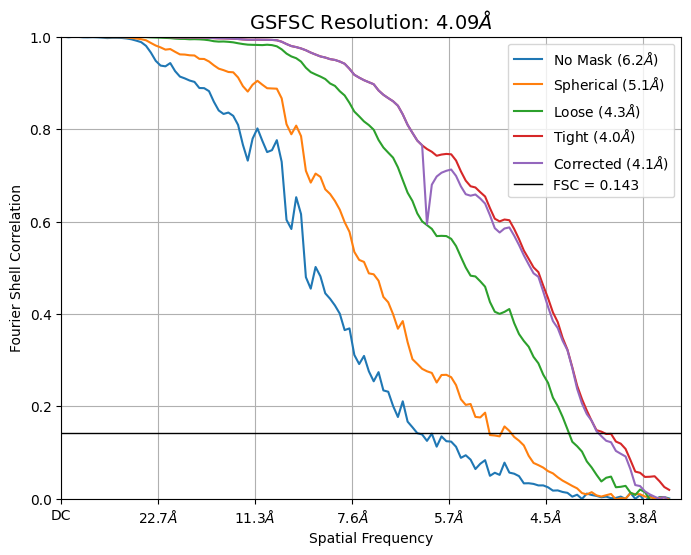

In [ ]:
if __name__ == '__main__':
    # @title print out FSC plot
    # @markdown the plot will be save at the provided `json_dir`
    json_dir = f" {RESULT_DIR}/FSC_plot"
    default_dir = True # @param{type: "boolean"}
    if default_dir == False:
        # @markdown if default_dir set to `False` please type in the directory of the json file
        json_dir = "" # @param {type: "string"}
    # @markdown ---
    file_name = "job" # @param {type: "string"}
    file_name = file_name + ".json"

    file_path = os.path.join(json_dir.strip(), file_name.strip())
    with open(file_path, 'r') as f:
        job_data = json.load(f)

    volume_group = next(g for g in job_data['output_result_groups'] if g['type'] == 'volume')
    fsc_stats = volume_group['latest_summary_stats']
    fsc_info_json = fsc_stats.get('fsc_info', {})
    fsc_info_best_json = fsc_stats.get('fsc_info_best', fsc_info_json)

    fsc_data_for_plot = FSCData(fsc_info_best_json, fsc_info_json)
    N = fsc_info_best_json.get('N', 256)
    psize = fsc_info_best_json.get('psize', 1.0)
    radwn_max = N / 2.0

    # Generate the plot
    if fsc_data_for_plot.radwns is not None:
        print("FSC data found. Generating plot...")
        fig = plot_fscs(radwn_max, fsc_data_for_plot, N, psize)

        # Save the plot to a file and display it
        fig.savefig(f'{json_dir.strip()}/fsc_plot.png', bbox_inches='tight', dpi=150)
        print("Plot saved as fsc_plot.png")
        plt.show()
    else:
        print("Error: Could not find 'radwns' array in the FSC data.")

---
## Result Save

In [ ]:
# @title Save the resutls
!rsync -av {PROJECT_DIR}/CS-{PROJ_NAME} {RESULT_DIR}

sending incremental file list
rsync: [sender] link_stat "/content/sparc_project/CS-10017_100_CRF" failed: No such file or directory (2)

sent 19 bytes  received 12 bytes  62.00 bytes/sec
total size is 0  speedup is 0.00
rsync error: some files/attrs were not transferred (see previous errors) (code 23) at main.c(1338) [sender=3.2.7]


In [ ]:
# @markdown ---
# @markdown time used
end_time = time.time()
print(f"End time recorded: {end_time}")

elapsed_time = end_time - start_time
elapsed_time = elapsed_time


hours = int(elapsed_time // 3600)
remaining_seconds = elapsed_time % 3600

minutes = int(remaining_seconds // 60)
seconds = round(remaining_seconds % 60, 3)

print(f"Time spend : {hours} h, {minutes} m, {seconds} s")


gpu_used = "T4 high" # @param ["CPU high", "T4", "T4 high", "L4"]
per_unit_cost_dict = {"L4" : 1.71, "T4 high" : 1.41, "T4" : 1.19, "CPU high" :  0.24}
per_unit_cost = per_unit_cost_dict[gpu_used]
print(f"unit price per hr {per_unit_cost}")

cost_units = per_unit_cost * elapsed_time / 3600

per_unit_US = 10.49 / 100

cost_price_US = cost_units * per_unit_US

print(f"unit cost : {round(cost_units, 4)}")
print(f"unit price US: {cost_price_US}")
print(f"unit price NTD: {cost_price_US * 30.76}")

End time recorded: 1762775410.4990098
Time spend : 0 h, 47 m, 26.316 s
unit price per hr 1.41
unit cost : 1.1148
unit price US: 0.11694325043878098
unit price NTD: 3.597174383496903
